In [1]:
#Import

%pip install xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\Lenovo ThinkPad T480\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [2]:
#Load dataset

df = pd.read_csv(r"C:\Users\Lenovo ThinkPad T480\Documents\CAREER\projects\cybersecurity-threat-assessment\data\clean_data.csv", sep=",")

df.head()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours),impact_score,likelihood,risk_score,Risk Category
0,China,2019,Phishing,Education,0.804402,0.773355,Hacker Group,Unpatched Software,VPN,0.873239,0.808856,0.000333,0.000270,Low
1,China,2019,Ransomware,Retail,0.620062,0.295770,Hacker Group,Unpatched Software,Firewall,0.985915,0.595945,0.000333,0.000199,Low
2,India,2017,Man-in-the-Middle,IT,0.383456,0.605949,Hacker Group,Weak Passwords,VPN,0.267606,0.427034,0.000667,0.000285,Low
3,UK,2024,Ransomware,Telecommunications,0.411499,0.659416,Nation-state,Social Engineering,AI-based Detection,0.084507,0.420476,0.001333,0.000561,High
4,Germany,2018,Man-in-the-Middle,IT,0.742889,0.810898,Insider,Social Engineering,VPN,0.943662,0.803446,0.001333,0.001071,High


In [3]:
df["Risk Category"].value_counts()          

Risk Category
Medium    1018
High       992
Low        990
Name: count, dtype: int64

In [4]:
# ==========================================
# 1. PROSES PEMBUATAN TARGET
# ==========================================
oe = OrdinalEncoder(categories=[["Low", "Medium", "High"]], handle_unknown="use_encoded_value", unknown_value=-1)
df["Risk Category Encoded"] = oe.fit_transform(df[["Risk Category"]])

# ==========================================
# 2. SEPARASI FITUR & TARGET (Mencegah Target Leakage)
# ==========================================
fitur_numerik = [
    "Financial Loss (in Million $)",
    "Number of Affected Users",
    "Incident Resolution Time (in Hours)"
]
fitur_kategorikal = [
     'Country', 'Attack Type', 'Target Industry',
    'Attack Source', 'Security Vulnerability Type', 'Defense Mechanism Used'
]

X_raw = df[fitur_numerik + fitur_kategorikal]  # eksplisit, bukan drop
y = df["Risk Category Encoded"].astype(int)

# ==========================================
# 3. SPLIT DATA TERLEBIH DAHULU
# ==========================================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================
# 4. OneHotEncoder + MinMaxScaler dalam ColumnTransformer
# fit HANYA di train → tidak ada leakage ke test
# ==========================================
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ("num", MinMaxScaler(), fitur_numerik),          # PATCH 1: scaler fit di train saja
    ("cat", OneHotEncoder(                            # PATCH 2: ganti get_dummies
        handle_unknown="ignore",
        sparse_output=False,
        drop="first"                                  # setara drop_first=True
    ), fitur_kategorikal)
])

X_train = preprocessor.fit_transform(X_train_raw)   # fit + transform di train
X_test  = preprocessor.transform(X_test_raw)        # transform saja, pakai parameter train

In [5]:
#XGBoost


model_xgb = XGBClassifier(
    n_estimators=200,         # jumlah boosting round
    learning_rate=0.1,        # eta: step size shrinkage (0–1)
    max_depth=6,              # kedalaman tree (default 6)
    min_child_weight=1,       # minimum sum hessian di child
    subsample=0.8,            # proporsi sampel per tree (0–1)
    colsample_bytree=0.8,     # proporsi fitur per tree
    gamma=0,                  # minimum loss reduction untuk split
    reg_alpha=0,              # L1 regularisasi
    reg_lambda=1,             # L2 regularisasi
    scale_pos_weight=1,       # untuk imbalanced
    
    # PINDAH KE SINI: early_stopping_rounds ditaruh di dalam model utama
    early_stopping_rounds=20,  
    
    eval_metric="mlogloss",    
    random_state=42,
    n_jobs=-1
)

#train
model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

[0]	validation_0-mlogloss:1.07570


C:\Users\Lenovo ThinkPad T480\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\callback.py:385: UserWarning: [14:23:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  self.starting_round = model.num_boosted_rounds()


[50]	validation_0-mlogloss:0.94331
[69]	validation_0-mlogloss:0.95153


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,20
,enable_categorical,False
,eval_metric,'mlogloss'


In [6]:
#Prediksi XGBoost

xgb_pred = model_xgb.predict(X_test)
print(confusion_matrix(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

[[123  35  40]
 [ 58  66  80]
 [ 14  66 118]]
              precision    recall  f1-score   support

           0       0.63      0.62      0.63       198
           1       0.40      0.32      0.36       204
           2       0.50      0.60      0.54       198

    accuracy                           0.51       600
   macro avg       0.51      0.51      0.51       600
weighted avg       0.51      0.51      0.51       600



In [7]:
#Random Forest

model_rfc = RandomForestClassifier(
    n_estimators=100,      # jumlah pohon (default 100)
    criterion="gini",
    max_depth=None,        # kedalaman pohon
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",   # fitur per split: 'sqrt','log2', int, float
    bootstrap=True,        # sampling dengan replacement
    class_weight="balanced",
    n_jobs=-1,             # gunakan semua core CPU
    random_state=42
)

#Train
model_rfc.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
#Prediksi Random Forest
from sklearn.metrics import classification_report, confusion_matrix

rfc_pred = model_rfc.predict(X_test)
print(confusion_matrix(y_test, rfc_pred))
print(classification_report(y_test, rfc_pred))

[[123  43  32]
 [ 55  90  59]
 [ 17  66 115]]
              precision    recall  f1-score   support

           0       0.63      0.62      0.63       198
           1       0.45      0.44      0.45       204
           2       0.56      0.58      0.57       198

    accuracy                           0.55       600
   macro avg       0.55      0.55      0.55       600
weighted avg       0.55      0.55      0.55       600



In [9]:
#Decision Tree

model_dt = DecisionTreeClassifier(
    criterion="gini",      # 'gini' atau 'entropy'
    max_depth=5,           # kedalaman maksimum (None = unlimited)
    min_samples_split=10,  # min sampel untuk split node
    min_samples_leaf=5,    # min sampel di leaf node
    max_features=None,     # jumlah fitur untuk split: None, 'sqrt', 'log2'
    class_weight="balanced",
    random_state=42
)

#Train
model_dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [10]:
#Prediksi Decision Tree

dt_pred = model_dt.predict(X_test)
print(confusion_matrix(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

[[114  45  39]
 [ 49  73  82]
 [ 15  54 129]]
              precision    recall  f1-score   support

           0       0.64      0.58      0.61       198
           1       0.42      0.36      0.39       204
           2       0.52      0.65      0.58       198

    accuracy                           0.53       600
   macro avg       0.53      0.53      0.52       600
weighted avg       0.53      0.53      0.52       600



Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best Params: {'max_depth': None, 'min_samples_leaf': 10, 'n_estimators': 100}
Best CV F1 : 0.5233907973922503
              precision    recall  f1-score   support

         Low       0.63      0.64      0.63       198
      Medium       0.41      0.34      0.37       204
        High       0.52      0.60      0.56       198

    accuracy                           0.53       600
   macro avg       0.52      0.53      0.52       600
weighted avg       0.52      0.53      0.52       600



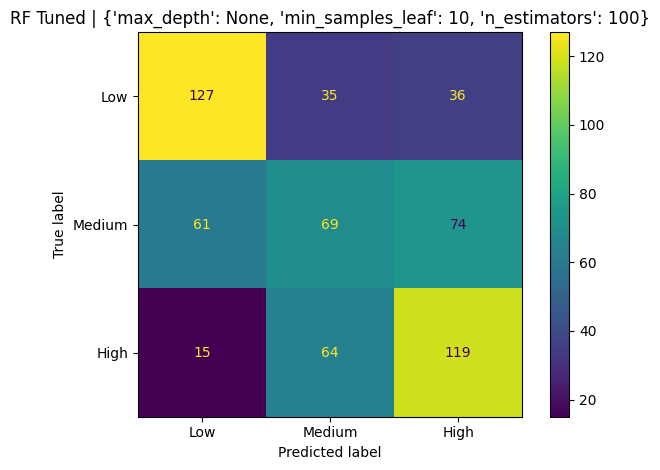

In [11]:
param_grid = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [3, 5, 7, None],
    "min_samples_leaf": [1, 5, 10]
}

gs = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1,
    refit=True
)

gs.fit(X_train, y_train)  # pakai X_train hasil preprocessor.fit_transform

print("Best Params:", gs.best_params_)
print("Best CV F1 :", gs.best_score_)

# ==========================================
# PREDIKSI & EVALUASI
# ==========================================
best_model = gs.best_estimator_
y_pred_best = best_model.predict(X_test)  # pakai X_test hasil preprocessor.transform

print(classification_report(y_test, y_pred_best, target_names=["Low", "Medium", "High"]))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=["Low", "Medium", "High"]
)
plt.title(f"RF Tuned | {gs.best_params_}")
plt.tight_layout()
plt.show()